# PyTorch Computer Vision — AI vs Real Image Detection

Binary classification — `0` = real, `1` = AI-generated — built around the Etsy use case: detecting synthetic product images mixed in with authentic artist work.

| Use case | Why it matters |
|---|---|
| Fake art / AI-generated image filtering | Protect authentic sellers on the platform |
| Deepfake detection | Prevent identity and content fraud |
| Dataset cleaning | Remove synthetic images before training downstream models |

Three models of increasing complexity — linear baseline → linear + non-linearity → CNN from scratch.

## 1. Setup

Imports, path resolution, and device selection. Falls back through CUDA → MPS → CPU so the notebook runs on any machine.

In [11]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR     = PROJECT_ROOT / "Data"
IMAGE_DIR    = DATA_DIR / "images_final_sample"
TRAIN_CSV    = DATA_DIR / "train.csv"
TEST_CSV     = DATA_DIR / "test.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

print(f"torch     : {torch.__version__}")
print(f"device    : {device}")
for p in [TRAIN_CSV, TEST_CSV, IMAGE_DIR]:
    print(f"  {'OK' if p.exists() else 'MISSING'}: {p.relative_to(PROJECT_ROOT)}")

torch     : 2.5.1
device    : mps
  OK: Data/train.csv
  OK: Data/test.csv
  OK: Data/images_final_sample


## 2. Dataset

Images live in a flat directory (`images_final_sample/`) with labels in a CSV — not an ImageFolder layout, so we use a custom `Dataset`. Train transform includes light augmentation; eval transform is deterministic. Both use ImageNet normalisation to keep pixel ranges consistent.

In [12]:
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class EtsyImageDataset(Dataset):
    def __init__(self, df_or_path, image_dir, transform=None):
        if isinstance(df_or_path, pd.DataFrame):
            self.df = df_or_path.reset_index(drop=True)
        else:
            self.df = pd.read_csv(df_or_path)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.image_dir / row["image_id"]).convert("RGB")
        label = int(row["ground_truth"])
        if self.transform:
            img = self.transform(img)
        return img, label


# test.csv has no labels — split train.csv into train/val instead
from sklearn.model_selection import train_test_split

full_df = pd.read_csv(TRAIN_CSV)
train_df, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df["ground_truth"])

train_data = EtsyImageDataset(train_df, IMAGE_DIR, transform=train_transform)
test_data  = EtsyImageDataset(val_df,   IMAGE_DIR, transform=eval_transform)

print(f"train: {len(train_data):,}   val: {len(test_data):,}")

train: 3,840   val: 960


### Input and output shape

Confirm the tensor shape and label format coming out of the dataset before wiring it into any model.

In [13]:
img, label = train_data[0]
print(f"tensor shape : {img.shape}   (C, H, W)")
print(f"label        : {label}   -> {'AI-generated' if label else 'Real'}")

tensor shape : torch.Size([3, 128, 128])   (C, H, W)
label        : 0   -> Real


### Visual sanity check

Five real and five AI-generated samples side by side. Good for catching transform issues and getting a feel for what the model will see.

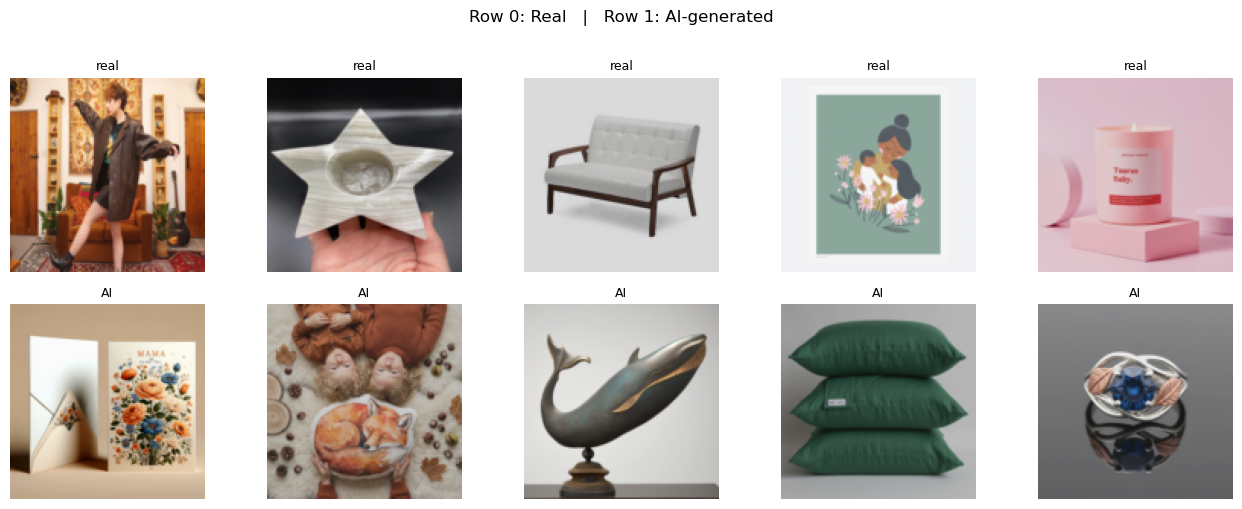

In [14]:
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)


real_idx = train_data.df[train_data.df["ground_truth"] == 0].index[:5].tolist()
ai_idx   = train_data.df[train_data.df["ground_truth"] == 1].index[:5].tolist()

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for col, (ri, ai) in enumerate(zip(real_idx, ai_idx)):
    img_r, _ = train_data[ri]
    img_a, _ = train_data[ai]
    axes[0, col].imshow(denorm(img_r).permute(1, 2, 0)); axes[0, col].set_title("real", fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(denorm(img_a).permute(1, 2, 0)); axes[1, col].set_title("AI",   fontsize=9); axes[1, col].axis("off")
plt.suptitle("Row 0: Real   |   Row 1: AI-generated", y=1.01)
plt.tight_layout()
plt.show()

## 3. DataLoaders

Shuffle on train, fixed order on test. `num_workers=0` keeps it portable across environments.

In [15]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

X_b, y_b = next(iter(train_loader))
print(f"batch X: {X_b.shape}   y: {y_b.shape}")

batch X: torch.Size([32, 3, 128, 128])   y: torch.Size([32])


## 4. Training utilities

`train_epoch` and `eval_epoch` handle a single pass through a loader. `fit` wraps them, logs loss and accuracy per epoch, and returns the full history and total training time. All three models share the same loop — the only differences are the model, optimiser, and learning rate.

In [16]:
def accuracy(logits, y):
    preds = (torch.sigmoid(logits) >= 0.5).long().squeeze()
    return (preds == y).float().mean().item()


def train_epoch(model, loader, loss_fn, opt):
    model.train()
    loss_sum, acc_sum = 0.0, 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss   = loss_fn(logits, y.unsqueeze(1).float())
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()
        acc_sum  += accuracy(logits.detach(), y)
    return loss_sum / len(loader), acc_sum / len(loader)


def eval_epoch(model, loader, loss_fn):
    model.eval()
    loss_sum, acc_sum = 0.0, 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss_sum += loss_fn(logits, y.unsqueeze(1).float()).item()
            acc_sum  += accuracy(logits, y)
    return loss_sum / len(loader), acc_sum / len(loader)


def fit(model, train_loader, test_loader, loss_fn, opt, epochs=5):
    h = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    t0 = time.time()
    for ep in range(epochs):
        tr_l, tr_a = train_epoch(model, train_loader, loss_fn, opt)
        te_l, te_a = eval_epoch(model,  test_loader,  loss_fn)
        h["train_loss"].append(tr_l); h["train_acc"].append(tr_a)
        h["test_loss"].append(te_l);  h["test_acc"].append(te_a)
        print(f"[{ep+1}/{epochs}]  train {tr_l:.4f}/{tr_a:.4f}  test {te_l:.4f}/{te_a:.4f}")
    elapsed = time.time() - t0
    print(f"done in {elapsed:.1f}s")
    return h, elapsed

## 5. Model 0 — Linear baseline

Flatten the image to a vector and pass through two linear layers with no activation. No spatial awareness — purely a floor to beat. SGD with a conservative learning rate keeps it honest.

In [17]:
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE * IMG_SIZE * 3, 64),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model_0 = ModelV0().to(device)
loss_fn = nn.BCEWithLogitsLoss()
opt_0   = torch.optim.SGD(model_0.parameters(), lr=0.01)

print(f"params: {sum(p.numel() for p in model_0.parameters()):,}")

params: 3,145,857


In [18]:
EPOCHS = 5
history_0, time_0 = fit(model_0, train_loader, test_loader, loss_fn, opt_0, epochs=EPOCHS)

[1/5]  train 0.8827/0.5497  test 0.6829/0.5281
[2/5]  train 0.6782/0.5664  test 0.6792/0.5406
[3/5]  train 0.6692/0.5849  test 0.6928/0.5437
[4/5]  train 0.6675/0.5870  test 0.6849/0.5458
[5/5]  train 0.6620/0.6039  test 0.6991/0.5333
done in 6137.7s


## 6. Model 1 — Non-linearity

Same linear structure, but with ReLU activations between layers and a wider hidden dimension. Switching to Adam here — SGD struggles once the network gets wider. This is the minimum needed to learn non-linear decision boundaries.

In [19]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE * IMG_SIZE * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model_1 = ModelV1().to(device)
opt_1   = torch.optim.Adam(model_1.parameters(), lr=1e-3)

print(f"params: {sum(p.numel() for p in model_1.parameters()):,}")

params: 12,599,681


In [20]:
history_1, time_1 = fit(model_1, train_loader, test_loader, loss_fn, opt_1, epochs=EPOCHS)

[1/5]  train 1.3062/0.5398  test 1.2385/0.5437
[2/5]  train 0.8304/0.5576  test 0.7098/0.5458
[3/5]  train 0.6585/0.6078  test 0.6783/0.5865
[4/5]  train 0.6392/0.6320  test 0.6731/0.5917
[5/5]  train 0.6303/0.6435  test 0.6588/0.5938
done in 12222.1s


## 7. Model 2 — CNN from scratch

Three conv blocks, each with BatchNorm, ReLU, and MaxPool. BatchNorm stabilises training across batches; dropout in the classifier head reduces overfitting. The key motivation for a CNN here: AI-generated images carry repeating texture artefacts and frequency patterns that spatial filters can learn to detect — something a flat linear layer can't represent.

In [21]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),  # 128→64
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), # 64→32
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), # 32→16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))


model_2 = CNNModel().to(device)
opt_2   = torch.optim.Adam(model_2.parameters(), lr=1e-3)

print(f"params: {sum(p.numel() for p in model_2.parameters()):,}")

params: 4,218,625


In [22]:
history_2, time_2 = fit(model_2, train_loader, test_loader, loss_fn, opt_2, epochs=EPOCHS)

[1/5]  train 0.9584/0.5500  test 0.6641/0.5979
[2/5]  train 0.6706/0.5945  test 0.6601/0.6146
[3/5]  train 0.6637/0.5982  test 0.6424/0.6271
[4/5]  train 0.6510/0.6219  test 0.6431/0.6167
[5/5]  train 0.6563/0.6125  test 0.6445/0.6062
done in 1259.6s


## 8. Compare models

Summary table across all three models — accuracy, loss, parameter count, and training time — followed by loss and accuracy curves over training.

In [23]:
results = pd.DataFrame([
    {"model": "M0 linear",    "params": sum(p.numel() for p in model_0.parameters()), "test_acc": history_0["test_acc"][-1],  "test_loss": history_0["test_loss"][-1],  "train_s": round(time_0, 1)},
    {"model": "M1 +ReLU",     "params": sum(p.numel() for p in model_1.parameters()), "test_acc": history_1["test_acc"][-1],  "test_loss": history_1["test_loss"][-1],  "train_s": round(time_1, 1)},
    {"model": "M2 CNN",        "params": sum(p.numel() for p in model_2.parameters()), "test_acc": history_2["test_acc"][-1],  "test_loss": history_2["test_loss"][-1],  "train_s": round(time_2, 1)},
]).set_index("model")

results[["test_acc", "test_loss"]] = results[["test_acc", "test_loss"]].round(4)
display(results)

,params,test_acc,test_loss,train_s
model,,,,
M0 linear,3145857,0.5333,0.6991,6137.7
M1 +ReLU,12599681,0.5938,0.6588,12222.1
M2 CNN,4218625,0.6062,0.6445,1259.6


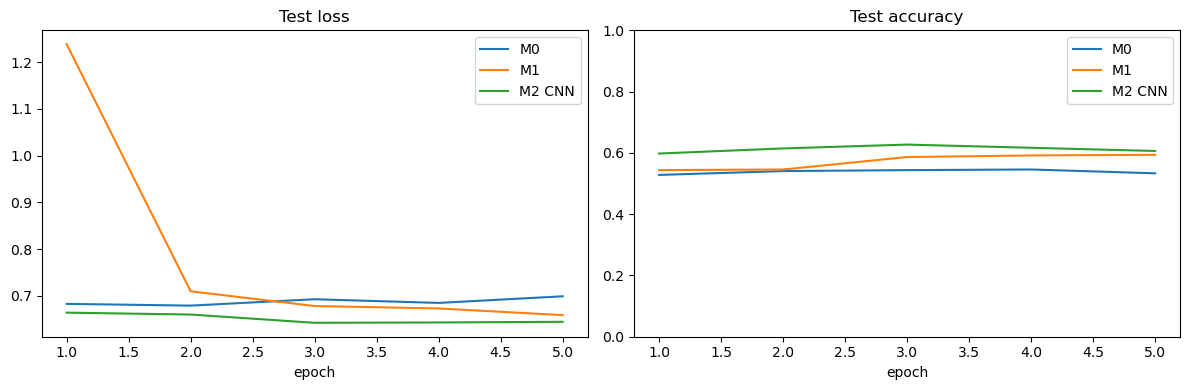

In [24]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, h in [("M0", history_0), ("M1", history_1), ("M2 CNN", history_2)]:
    ax1.plot(epochs, h["test_loss"], label=name)
    ax2.plot(epochs, h["test_acc"],  label=name)

ax1.set_title("Test loss");     ax1.legend(); ax1.set_xlabel("epoch")
ax2.set_title("Test accuracy"); ax2.legend(); ax2.set_ylim(0, 1); ax2.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 9. Evaluate best model

Full  on the CNN — precision, recall, and F1 per class. False negatives (AI labelled as real) are the more costly error for platform integrity.

In [25]:
def get_preds(model, loader):
    model.eval()
    probs_all, preds_all, labels_all = [], [], []
    with torch.no_grad():
        for X, y in loader:
            logits = model(X.to(device)).squeeze(1)
            p = torch.sigmoid(logits).cpu()
            probs_all.append(p)
            preds_all.append((p >= 0.5).long())
            labels_all.append(y)
    return (
        torch.cat(probs_all).numpy(),
        torch.cat(preds_all).numpy(),
        torch.cat(labels_all).numpy(),
    )


probs, preds, labels = get_preds(model_2, test_loader)
print(classification_report(labels, preds, target_names=["real", "ai_generated"]))

              precision    recall  f1-score   support

        real       0.58      0.84      0.69       497
ai_generated       0.67      0.35      0.46       463

    accuracy                           0.61       960
   macro avg       0.63      0.60      0.58       960
weighted avg       0.63      0.61      0.58       960



### Predictions on a random sample

Green title = correct, red = wrong. Useful for spotting patterns in the failures — e.g. whether misclassified images tend to look ambiguous or have similar visual properties.

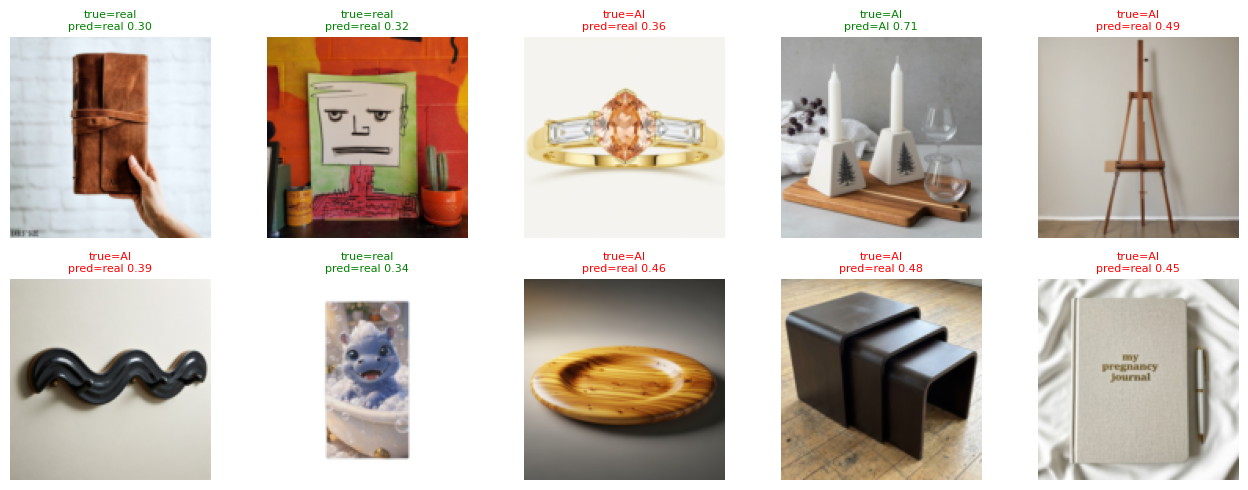

In [26]:
idxs = np.random.choice(len(test_data), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

for ax, idx in zip(axes.flatten(), idxs):
    img, true = test_data[idx]
    pred, prob = preds[idx], probs[idx]
    ax.imshow(denorm(img).permute(1, 2, 0))
    color = "green" if pred == true else "red"
    ax.set_title(f"true={'AI' if true else 'real'}\npred={'AI' if pred else 'real'} {prob:.2f}",
                 color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Confusion matrix

Breaks down exactly where the model is failing. False positives (real → AI) affect legitimate sellers; false negatives (AI → real) let synthetic images through — the more damaging error for platform integrity.

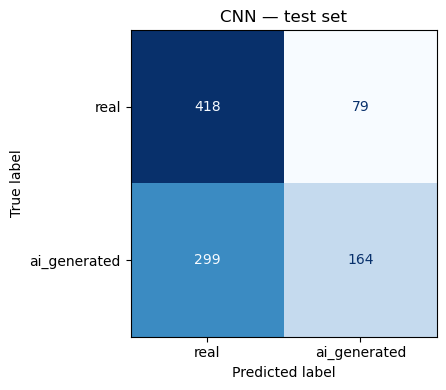

,count
metric,
true negative (real → real),418
false positive (real → AI),79
false negative (AI → real),299
true positive (AI → AI),164


In [27]:
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["real", "ai_generated"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("CNN — test set")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
display(pd.DataFrame([
    {"metric": "true negative  (real → real)",   "count": tn},
    {"metric": "false positive (real → AI)",      "count": fp},
    {"metric": "false negative (AI  → real)",     "count": fn},
    {"metric": "true positive  (AI  → AI)",       "count": tp},
]).set_index("metric"))

## 11. Save & load

Saves the CNN's `state_dict` to `artifacts/`. After reloading we assert the predictions match exactly — confirms the save/load is lossless and the model is ready to use outside this notebook.

In [28]:
save_path = ARTIFACT_DIR / "model_2_cnn.pth"
torch.save(model_2.state_dict(), save_path)
print(f"saved: {save_path}")

# reload and sanity check
model_loaded = CNNModel().to(device)
model_loaded.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
model_loaded.eval()

_, preds_reload, _ = get_preds(model_loaded, test_loader)
assert np.array_equal(preds, preds_reload)
print("reload OK — predictions match")

saved: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection/artifacts/model_2_cnn.pth
reload OK — predictions match
